In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from matplotlib.lines import Line2D
from tqdm import tqdm

In [2]:
plt.rcParams['svg.fonttype'] = 'none'

cm = 1/2.54

# 每次调用font dict
fontdict = dict(fontsize=7)

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'


contrast_3 = ['#004488', '#BB5566','#DDAA33']

sns.set_theme(style='ticks', rc={"lines.linewidth": 1, 'font.size': 7, 'legend.fontsize': 7,'legend.title_fontsize': 7, 'axes.labelsize': 7, 'xtick.labelsize': 7, 'ytick.labelsize': 7, })

In [ ]:
import sys
sys.path.append('..')

from src.run_decoding import load_roi_data

bids_root = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS'
ref = 'bipolar'
roi = 'SMCl'
description = 'Repeat'
phase = 'Delay'
band = 'highgamma'
datatype = 'articulator'
tmin = 0
tmax = 1

X, y, _ = load_roi_data(bids_root, ref, roi, description, phase, band, datatype, tmin, tmax)

In [ ]:
from src.decoder import get_cv_predict
from ieeg.calc.oversample import MinimumNaNSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from mne.decoding import Vectorizer
from sklearn.metrics import confusion_matrix
import numpy as np

# 选择要用的 ROI 数据文件（这里取第一个）。
X_np = np.asarray(X[0])
y_np = np.asarray(y[0])
print(f"Loaded X shape={X_np.shape}, y shape={y_np.shape}, unique labels={np.unique(y_np)}")

# 交叉验证与 decoder（沿用默认 MinimumNaNSplit + PCA+SVC，sample_fold 在 get_cv_predict 内部被调用）
cv = MinimumNaNSplit(n_splits=10, n_repeats=5)
decoder = make_pipeline(
    Vectorizer(),
    StandardScaler(),
    PCA(n_components=0.85, random_state=42),
    SVC(kernel="linear", random_state=42),
)

# Out-of-fold 预测
y_pred = get_cv_predict(
    X_np,
    y_np,
    cv,
    decoder,
    n_jobs=-1,
)
acc = (y_pred == y_np).mean()
# 映射顺序 0:dorsal, 1:high_vowel, 2:labial, 3:low_vowel
label_names = ['dorsal', 'high vowel', 'labial', 'low vowel']
label_ids = list(range(len(label_names)))  # [0,1,2,3]

conf_mat = confusion_matrix(y_np, y_pred, labels=label_ids, normalize="true")
conf_mat_counts = confusion_matrix(y_np, y_pred, labels=label_ids, normalize=None)
print(f"CV accuracy (mean OOF): {acc:.3f}")
conf_mat

Loaded X shape=(204, 42, 128), y shape=(204,), unique labels=[0 1 2 3]


CV folds: 100%|██████████| 50/50 [00:00<00:00, 173.31it/s]


CV accuracy (mean OOF): 0.431


array([[0.47916667, 0.0625    , 0.35416667, 0.10416667],
       [0.24074074, 0.42592593, 0.14814815, 0.18518519],
       [0.33333333, 0.16666667, 0.44444444, 0.05555556],
       [0.14583333, 0.25      , 0.22916667, 0.375     ]])

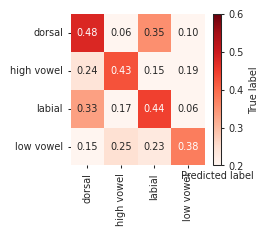

In [ ]:
fig, ax = plt.subplots(figsize=(5.5*cm, 5*cm))

a = sns.heatmap(
    conf_mat,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    cbar=True,
    vmin=0.2,
    vmax=0.6,
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax,
)

for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both',)
    plt.setp(ax.spines.values(), linewidth=.75)

ax.set_xlabel("Predicted label", fontsize=7)
ax.set_ylabel("True label", fontsize=7)

plt.savefig(f'img/misc/confusion_matrix_delay_SMC.svg',dpi=300,bbox_inches='tight')